## Lecture 01 - 04/08/2026

Prof. Pedro Henrique de Almeida Konzen.
Avaliação: artigo sobre um problema a ser resolvido com métodos numéricos vistos na disciplina. Apresentar em formato de seminário.
(Escolher o  tema [linkado com a tese] e um tema da disciplina que possa ser relacionado. O professor irá avaliar se é viável ou não.)

In [4]:
# Exercise 1.2.2:

name = input("Digite seu nome: ")
print(f"Hello, {name}!!!")

Hello, Éderson Passos!!!


## Lecture 04 - 13/08/2026

## 1.1 Band Matrix

In [13]:
size_float = 8
# matrix n x n
n = 100_000
print(f"Storage: {n*n*size_float/1024**3} GB")

Storage: 74.50580596923828 GB


In [14]:
# Example 1.1.2: 1D Poisson Equation
import numpy as np
n = 11
h = 1/(n-1)
xx = np.linspace(0, 1, n)
# Matrix
Ab = np.zeros((3,n))
u_diagonal = 1
l_diagonal = 1

def index(i, j):
    return u_diagonal + i - j, j

function = lambda x: np.pi**2*np.sin(np.pi*x)
b = np.zeros(n)

# Build the matrix
Ab[index(0,0)] = 1.0

for i in range(1, n-1):
    Ab[index(i,i)] = 2.0
    Ab[index(i,i-1)] = -1.0
    Ab[index(i,i+1)] = -1.0
    b[i] = function(xx[i])

Ab[index(n-1,n-1)] = 1.0
print(Ab)
print(b)

[[ 0.  0. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
 [ 1.  2.  2.  2.  2.  2.  2.  2.  2.  2.  1.]
 [-1. -1. -1. -1. -1. -1. -1. -1. -1.  0.  0.]]
[0.         3.04987549 5.80120791 7.98467769 9.38655158 9.8696044
 9.38655158 7.98467769 5.80120791 3.04987549 0.        ]


In [15]:
def solve_tribanded(ab, b):
    a = ab.copy()
    x = b.copy()
    n = b.size
    # eliminação
    for i in range(1,n):
        w = a[2,i-1]/a[1,i-1]
        a[1,i] -= w * a[0,i]
        x[i] -= w * x[i-1]
    # resolve
    x[n-1] = x[n-1]/a[1,n-1]
    for i in range(n-2,-1,-1):
        x[i] = (x[i] - a[0,i+1]*x[i+1])/a[1,i]
    return x

u_diagonal = solve_tribanded(Ab, b)
print(u_diagonal)

[  0.          31.15711487  59.26435425  81.57038572  95.8917395
 100.8265417   95.8917395   81.57038572  59.26435425  31.15711487
   0.        ]


## Lecture 18/08/2026

### Exemple 1.1.3.(Poisson 2D Equation)

In [5]:
import numpy as np
from scipy.linalg import solve_banded


# malha
n = 100
h = 1/(n-1)

xx = np.linspace(0, 1, n)
yy = np.linspace(0, 1, n)

# fonte
def f(x,y):
    return 2 * np.pi**2 * np.sin(np.pi*x) * np.sin(np.pi*y)

# sistema discreto
upper = lower = n-2
ab = np.zeros((upper+lower+1, (n-2)**2))
b = np.empty((n-2)**2)

# índice no formato banda
def ind(k, l):
    return upper + k - l, l

for j in np.arange(2,n):
    for i in np.arange(2,n):

        # enumeração dos nodos computacionais
        k = i-2 + (j-2)*(n-2)

        # vetor b
        b[k] = h**2 * f(xx[i-1], yy[j-1])

        # matriz ab
        ab[ind(k,k)] = 4.

        if (j == 2):
            if (i == 2):
                ab[ind(k,k+1)] = -1.
                ab[ind(k,k+n-2)] = -1.
            elif (i <= n-2):
                ab[ind(k,k-1)] = -1.
                ab[ind(k,k+1)] = -1.
                ab[ind(k,k+n-2)] = -1.
            else: # i == n-1
                ab[ind(k,k-1)] = -1.
                ab[ind(k,k+n-2)] = -1.
        elif (j <= n-2):
            if (i == 2):
                ab[ind(k,k-(n-2))] = -1.
                ab[ind(k,k+1)] = -1.
                ab[ind(k,k+n-2)] = -1.
            elif (i <= n-2):
                ab[ind(k,k-1)] = -1.
                ab[ind(k,k-(n-2))] = -1.
                ab[ind(k,k+1)] = -1.
                ab[ind(k,k+n-2)] = -1.
            else: # i == n-1
                ab[ind(k,k-1)] = -1.
                ab[ind(k,k-(n-2))] = -1.
                ab[ind(k,k+n-2)] = -1.
        else: # j == n-1
            if (i == 2):
                ab[ind(k,k-(n-2))] = -1.
                ab[ind(k,k+1)] = -1.
            elif (i <= n-2):
                ab[ind(k,k-1)] = -1.
                ab[ind(k,k-(n-2))] = -1.
                ab[ind(k,k+1)] = -1.
            else: # i == n-1
                ab[ind(k,k-1)] = -1.
                ab[ind(k,k-(n-2))] = -1.

# resolve
u = solve_banded((lower, upper), ab, b)

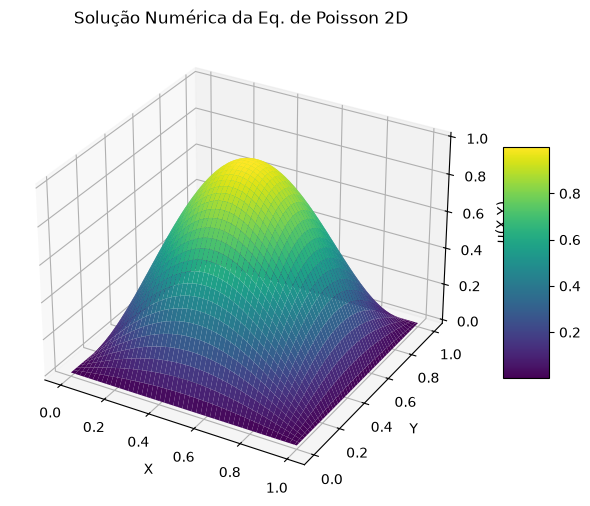

In [9]:
import matplotlib.pyplot as plt

X, Y = np.meshgrid(xx, yy)
U = np.zeros_like(X)

# As bordas de U já são zero (condição de contorno padrão)
# Os nodos internos recebem os valores de u.
# A reestruturação de u para o formato 2D segue a ordem dos laços:
U[1:-1, 1:-1] = u.reshape((n-2, n-2))

# Plotagem da superfície
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, U, cmap='viridis', edgecolor='none')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('u(X,Y)')
ax.set_title('Solução Numérica da Eq. de Poisson 2D')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

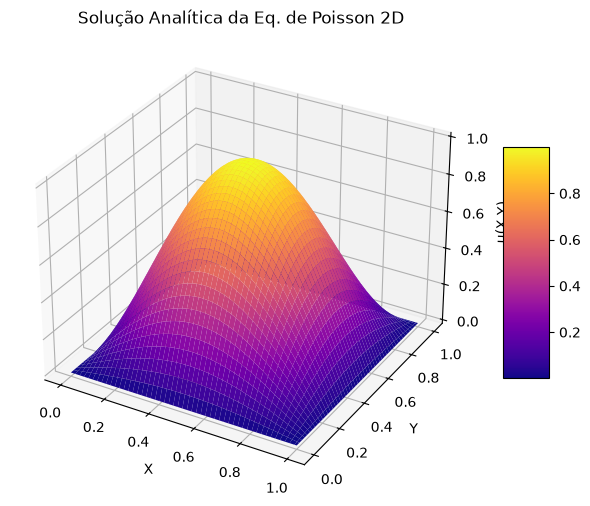

In [10]:
# Solução analítica
U_exata = np.sin(np.pi * X) * np.sin(np.pi * Y)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf_ex = ax.plot_surface(X, Y, U_exata, cmap='plasma', edgecolor='none')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('u(X,Y)')
ax.set_title('Solução Analítica da Eq. de Poisson 2D')
fig.colorbar(surf_ex, shrink=0.5, aspect=5)
plt.show()

Norma de Frobenius do Erro: 4.154083e-03


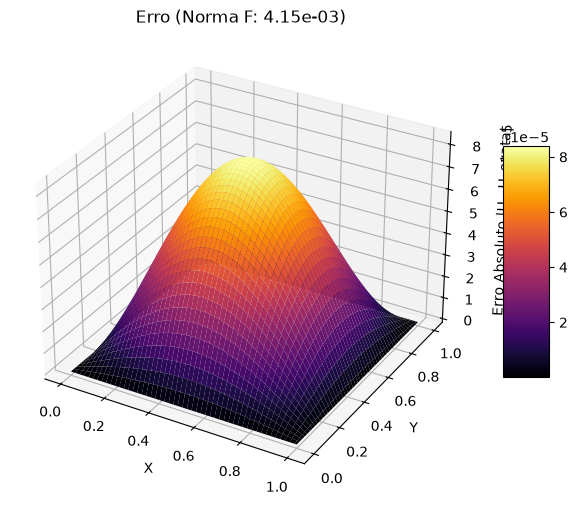

In [11]:
from numpy.linalg import norm

# Erro absoluto
Erro = np.abs(U - U_exata)

# Norma de Frobenius do Erro
norma_F = norm(Erro, 'fro')
print(f"Norma de Frobenius do Erro: {norma_F:.6e}")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf_err = ax.plot_surface(X, Y, Erro, cmap='inferno', edgecolor='none')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Erro Absoluto |U - U_exata|')
ax.set_title(f'Erro (Norma F: {norma_F:.2e})')
fig.colorbar(surf_err, shrink=0.5, aspect=5)
plt.show()

## Lecture 20/08/2026

### COO Format
Used to storage, not for computantion.

In [1]:
from scipy.sparse import coo_array

data = [2.,1.,3.,2.,-1.,-1.,-2.,1.]
row = [0,0,1,1,1,2,2,3]
col = [0,2,1,2,3,1,2,3]
Acoo = coo_array((data, (row, col)), shape=(4,4))
print("Acoo = \n", Acoo)
print("A = \n", Acoo.toarray())

Acoo = 
 <COOrdinate sparse array of dtype 'float64'
	with 8 stored elements and shape (4, 4)>
  Coords	Values
  (0, 0)	2.0
  (0, 2)	1.0
  (1, 1)	3.0
  (1, 2)	2.0
  (1, 3)	-1.0
  (2, 1)	-1.0
  (2, 2)	-2.0
  (3, 3)	1.0
A = 
 [[ 2.  0.  1.  0.]
 [ 0.  3.  2. -1.]
 [ 0. -1. -2.  0.]
 [ 0.  0.  0.  1.]]


### CSR Format

In [3]:
from scipy.sparse import csr_array
Acsr = Acoo.tocsr()
print(f'd = {Acsr.data}')
print(f'c = {Acsr.indices}')
print(f'p = {Acsr.indptr}')

d = [ 2.  1.  3.  2. -1. -1. -2.  1.]
c = [0 2 1 2 3 1 2 3]
p = [0 2 5 7 8]


### CSC Format

In [ ]:
from scipy.sparse import csc_array
Acsc = Acoo.tocsc()
l = Acsc.indices
p = Acsc.indptr
print(f'd = {Acsc.data}')
print(f'l = {Acsc.indices}')
print(f'p = {Acsc.indptr}')

d = [ 2.  3. -1.  1.  2. -2. -1.  1.]
l = [0 1 2 0 1 2 1 3]
p = [0 1 3 6 8]


In [17]:
import numpy as np
from scipy.sparse import coo_array
from scipy.sparse.linalg import spsolve # Vamos usar o solver para matrizes esparsas gerais

# malha
n = 1000
h = 1/(n-1)

xx = np.linspace(0, 1, n)
yy = np.linspace(0, 1, n)

# fonte
def f(x,y):
    return 2 * np.pi**2 * np.sin(np.pi*x) * np.sin(np.pi*y)

# listas para o formato COO
data = []
row = []
col = []

# vetor b
b = np.empty((n-2)**2)

# Função auxiliar para adicionar elementos no formato COO
def add_element(r, c, val):
    row.append(r)
    col.append(c)
    data.append(val)

for j in np.arange(2,n):
    for i in np.arange(2,n):

        # enumeração dos nodos computacionais (k é o índice da nossa equação / linha atual)
        k = i-2 + (j-2)*(n-2)

        # vetor b
        b[k] = h**2 * f(xx[i-1], yy[j-1])

        # Diagonal principal (linha k, coluna k)
        add_element(k, k, 4.0)

        # Condições de contorno e vizinhos (em vez do ind(k, vizinho), passamos k e vizinho)
        if (j == 2):
            if (i == 2):
                add_element(k, k+1, -1.0)
                add_element(k, k+n-2, -1.0)
            elif (i <= n-2):
                add_element(k, k-1, -1.0)
                add_element(k, k+1, -1.0)
                add_element(k, k+n-2, -1.0)
            else: # i == n-1
                add_element(k, k-1, -1.0)
                add_element(k, k+n-2, -1.0)
        elif (j <= n-2):
            if (i == 2):
                add_element(k, k-(n-2), -1.0)
                add_element(k, k+1, -1.0)
                add_element(k, k+n-2, -1.0)
            elif (i <= n-2):
                add_element(k, k-1, -1.0)
                add_element(k, k-(n-2), -1.0)
                add_element(k, k+1, -1.0)
                add_element(k, k+n-2, -1.0)
            else: # i == n-1
                add_element(k, k-1, -1.0)
                add_element(k, k-(n-2), -1.0)
                add_element(k, k+n-2, -1.0)
        else: # j == n-1
            if (i == 2):
                add_element(k, k-(n-2), -1.0)
                add_element(k, k+1, -1.0)
            elif (i <= n-2):
                add_element(k, k-1, -1.0)
                add_element(k, k-(n-2), -1.0)
                add_element(k, k+1, -1.0)
            else: # i == n-1
                add_element(k, k-1, -1.0)
                add_element(k, k-(n-2), -1.0)

# Tamanho do sistema
num_eq = (n-2)**2

# Criando a matriz COO
A_coo = coo_array((data, (row, col)), shape=(num_eq, num_eq))

# Se você quiser resolver o sistema agora, é recomendável converter para CSR ou CSC primeiro (pois COO não suporta operações algébricas eficientemente)
A_csr = A_coo.tocsr()

In [18]:
# Resolve o sistema linear
u = spsolve(A_csr, b)

In [19]:
print(A_csr)

<Compressed Sparse Row sparse array of dtype 'float64'
	with 4976028 stored elements and shape (996004, 996004)>
  Coords	Values
  (0, 0)	4.0
  (0, 1)	-1.0
  (0, 998)	-1.0
  (1, 0)	-1.0
  (1, 1)	4.0
  (1, 2)	-1.0
  (1, 999)	-1.0
  (2, 1)	-1.0
  (2, 2)	4.0
  (2, 3)	-1.0
  (2, 1000)	-1.0
  (3, 2)	-1.0
  (3, 3)	4.0
  (3, 4)	-1.0
  (3, 1001)	-1.0
  (4, 3)	-1.0
  (4, 4)	4.0
  (4, 5)	-1.0
  (4, 1002)	-1.0
  (5, 4)	-1.0
  (5, 5)	4.0
  (5, 6)	-1.0
  (5, 1003)	-1.0
  (6, 5)	-1.0
  (6, 6)	4.0
  :	:
  (995997, 995997)	4.0
  (995997, 995998)	-1.0
  (995998, 995000)	-1.0
  (995998, 995997)	-1.0
  (995998, 995998)	4.0
  (995998, 995999)	-1.0
  (995999, 995001)	-1.0
  (995999, 995998)	-1.0
  (995999, 995999)	4.0
  (995999, 996000)	-1.0
  (996000, 995002)	-1.0
  (996000, 995999)	-1.0
  (996000, 996000)	4.0
  (996000, 996001)	-1.0
  (996001, 995003)	-1.0
  (996001, 996000)	-1.0
  (996001, 996001)	4.0
  (996001, 996002)	-1.0
  (996002, 995004)	-1.0
  (996002, 996001)	-1.0
  (996002, 996002)	4.0
  (99600

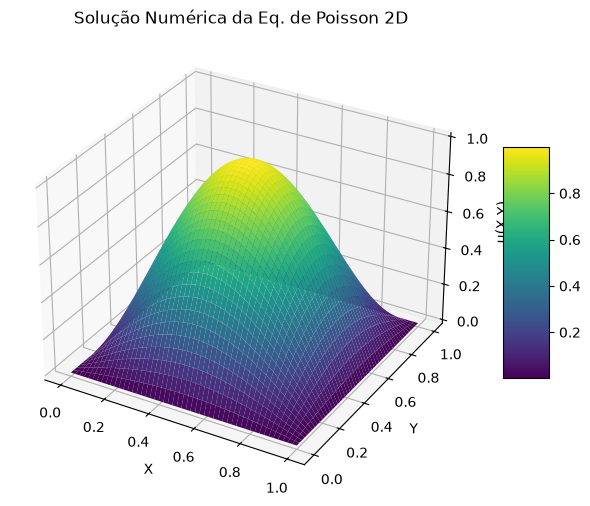

In [20]:
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve

u = spsolve(A_csr, b)

X, Y = np.meshgrid(xx, yy)
U = np.zeros_like(X)

# As bordas de U já são zero (condição de contorno padrão)
# Os nodos internos recebem os valores de u.
# A reestruturação de u para o formato 2D segue a ordem dos laços:
U[1:-1, 1:-1] = u.reshape((n-2, n-2))

# Plotagem da superfície
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, U, cmap='viridis', edgecolor='none')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('u(X,Y)')
ax.set_title('Solução Numérica da Eq. de Poisson 2D')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()